In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

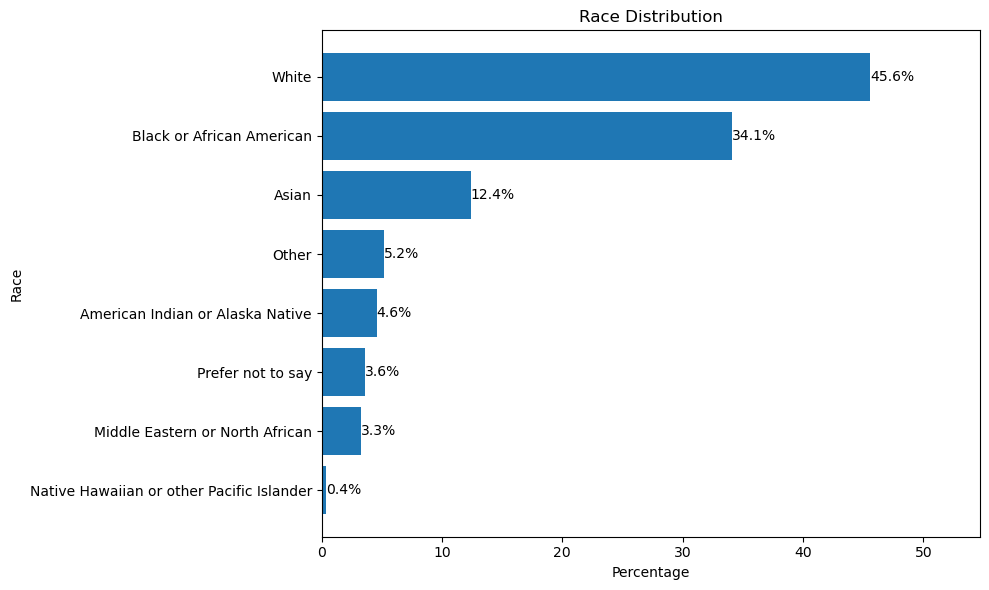

In [4]:
# Read the System-Wide Passenger Survey Data
df = pd.read_csv("MBTA_2023_System-Wide_Passenger_Survey_Data.csv")

# Get only bus data from survey
Bus_Survey_Data = df[df['service_mode'] == 'Bus']
unique_reporting_groups = Bus_Survey_Data['reporting_group'].unique()

# Calculate race distribution within bus passengers 
race_data = Bus_Survey_Data[(Bus_Survey_Data['measure'] == 'Race')]

# Calculate the average percentages for each race category
race_percentage = race_data.groupby('category')['weighted_percent'].mean().reset_index()
race_percentage = race_percentage.sort_values('weighted_percent', ascending=True)

# Create bar chart to display the distributions
plt.figure(figsize=(10, 6))
plt.barh(race_percentage['category'], race_percentage['weighted_percent'] * 100)
plt.title('Race Distribution')
plt.xlabel('Percentage')
plt.ylabel('Race')

for i, v in enumerate(race_percentage['weighted_percent']):
    plt.text(v*100, i, f'{v*100:.1f}%', va='center')
max_percentage = race_percentage['weighted_percent'].max() * 100
plt.xlim(0, max_percentage * 1.2)
plt.tight_layout()

# Show the plot
plt.show()

Top 10 Bus Routes (Minority Groups) by Weighted Percent:
     reporting_group  weighted_percent
909               23          0.903703
878               22          0.890091
669               15          0.870892
532               21          0.837399
1021              32          0.831628
29               104          0.817004
606               16          0.811798
349              111          0.782983
1697              66          0.683690
1402              39          0.671645


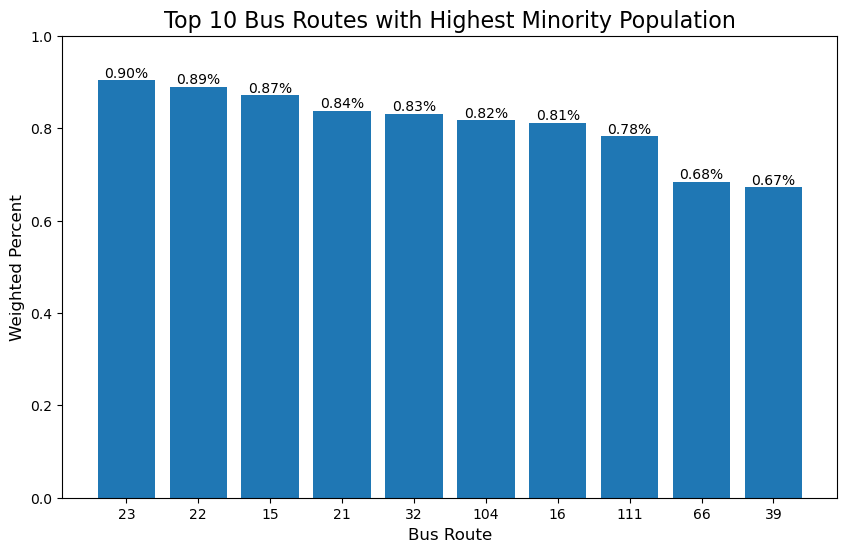

In [15]:
# Get data on top 10 bus routes with minority groups
minority_data = Bus_Survey_Data[(Bus_Survey_Data['measure'] == 'Title VI Minority') & (Bus_Survey_Data['category'] == 'Yes')]

# Filter for integer-valued bus routes

# This function is to only gather bus route numbers. Bus routes categorized by neighborhoods are not included in our project. 
def is_integer(s):
    try:
        int(s)
        return True
    except ValueError:
        return False
    
top_10_reporting_groups =minority_data[minority_data['reporting_group'].apply(is_integer)]

# Get top 10 from filtered data
top_10_reporting_groups = top_10_reporting_groups.nlargest(10, 'weighted_percent')


# Print the top 10 bus routes with highest minority percentages 
print("Top 10 Bus Routes (Minority Groups) by Weighted Percent:")
print(top_10_reporting_groups[['reporting_group', 'weighted_percent']])

# Plot the results 
plt.figure(figsize=(10, 6))
bars = plt.bar(top_10_reporting_groups['reporting_group'], top_10_reporting_groups['weighted_percent'])

plt.title('Top 10 Bus Routes with Highest Minority Population', fontsize=16)
plt.xlabel('Bus Route', fontsize=12)
plt.ylabel('Weighted Percent', fontsize=12)
plt.ylim(0, 1)  

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}%',
             ha='center', va='bottom')

Bus Route  Minority %  Low Income %
       23   90.370293     93.658214
       22   89.009073     87.862987
  28 & 29   88.733758     89.586268
       15   87.089185     91.390899
      111   78.298300     90.049993


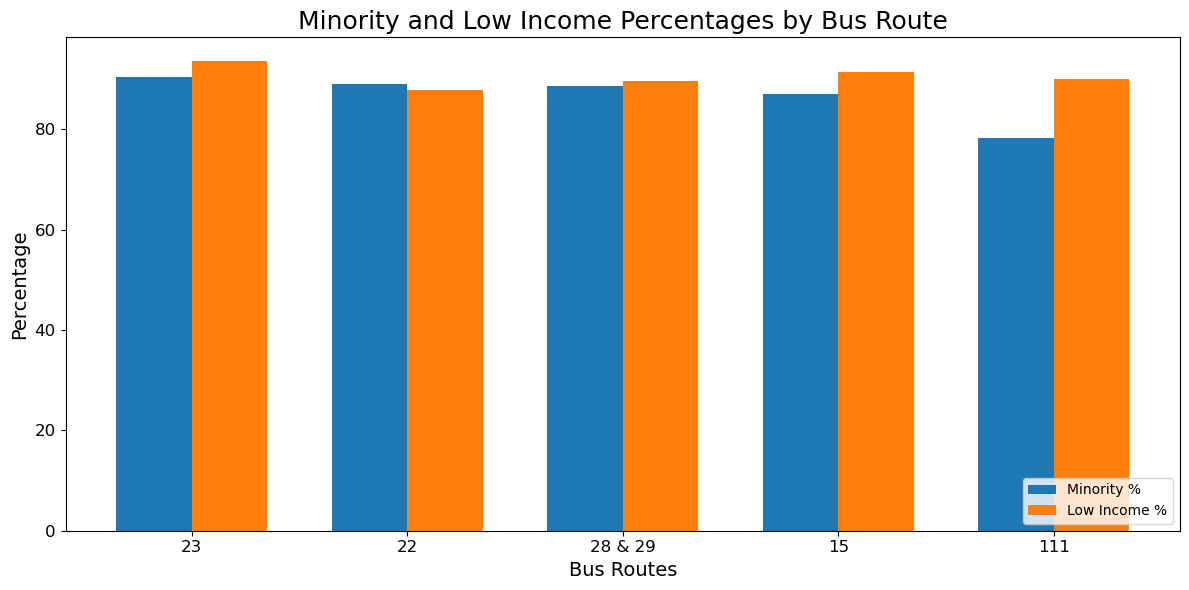

In [ ]:

# Assuming df is your original dataframe
Bus_Survey_Data = df[df['service_mode'] == 'Bus']

new_bus_routes = ['28 & 29','23', '22',  '15', '111']

# Function to get percentage for a specific measure and category
def get_percentage(data, measure, category):
    filtered_data = data[(data['measure'] == measure) & (data['category'] == category)]
    if not filtered_data.empty:
        return filtered_data['weighted_percent'].values[0]
    return 0

# Create a list to store the results
results = []

for route in new_bus_routes:
    route_data = Bus_Survey_Data[Bus_Survey_Data['reporting_group'] == route]
    
    minority_percent = get_percentage(route_data, 'Title VI Minority', 'Yes')
    low_income_percent = get_percentage(route_data, 'Title VI Low-Income', 'Yes')
    
    results.append({
        'Bus Route': route,
        'Minority %': minority_percent * 100,
        'Low Income %': low_income_percent * 100
    })

# Create a DataFrame from the results
result_df = pd.DataFrame(results)

# Sort the DataFrame by Minority % in descending order
result_df = result_df.sort_values('Minority %', ascending=False)

# Display the table
print(result_df.to_string(index=False))

# Create a bar plot
plt.figure(figsize=(12, 6))

x = range(len(new_bus_routes))
width = 0.35

plt.bar(x, result_df['Minority %'], width, label='Minority %')
plt.bar([i + width for i in x], result_df['Low Income %'], width, label='Low Income %')

plt.xlabel('Bus Routes', fontsize= 14)
plt.ylabel('Percentage', fontsize= 14)
plt.title('Minority and Low Income Percentages by Bus Route', fontsize = 18)
plt.xticks([i + width/2 for i in x], result_df['Bus Route'], fontsize= 12)
plt.yticks(fontsize= 12)
plt.legend(loc='lower right')


plt.tight_layout()
plt.show()